In [1]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import GridSpec
import matplotlib.gridspec as gridspec
import numpy as np
import glob
import pandas as pd
import math
from math import sqrt
import random
import scipy
from scipy.stats import mannwhitneyu

import skimage
import skimage.io
from skimage.morphology import disk
from skimage.filters import rank

import seaborn as sns

plt.style.use('styleNB.mplstyle')

wt = 'dHL60KW'
ko1 = 'dHL60TMEM154KO-clone1'
ko2 = 'dHL60TMEM154KO-clone12'


# Figure 2 Supplemental materials

Here we will consider data from two of the clonal Galvanin knockout cell lines. The second clone we tested was only considered only a smaller subset of experimental conditions, so only those conditions are plotted. Note that 'clone 2' written in the supplemental material is referred to as 'clone 12' here.

### Load in the date

In [2]:
f_compiled = '../../data/processed_3D_tracking/20240424_compiled_galvaninKOlines_tracking.csv'

df = pd.read_csv(f_compiled)
df = df[['cell', 'frame', 'x', 'y', 'z', 'celltype', 'E_V_cm',
       'date', 'trial', 'user']]
df = df[df.celltype != 'dHL60TMEM154KO-clone1galvanin-GFP-HA']

f_rescue_filtered = '../../data/processed_3D_tracking/20240424_compiled_galvaninKOlines_rescue_tracking_GFPplus.csv'
df_gfp = pd.read_csv(f_rescue_filtered)
df_gfp = df_gfp[['cell', 'frame', 'x', 'y', 'z',
       'celltype', 'E_V_cm', 'date', 'trial', 'user']]

df = pd.concat([df, df_gfp], ignore_index = True)

# df = df.replace('dHL60TMEM154KO-clone1', 'dHL60TMEM154KO')
# df = df.replace('dHL60TMEM154KO-clone12', 'dHL60TMEM154KO')

#  Step 1: Remove cells at the periphery
df_temp_ = pd.DataFrame()
for g, d_ in df.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    if np.any(d_.z > 280):
        continue
    elif np.any(d_.z < 20):
        continue
    
    # Append the row to the DataFrame using concat
    df_temp_ = pd.concat([df_temp_, d_], ignore_index=True)
    
df = df_temp_

# Step 2: Filter trajectories
df_filtered_tracks = pd.DataFrame()

for g, d_ in df.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    # Filter: skip short tracks based on unique frame count
    if len(d_['frame'].unique()) <= 20: #14:
        continue

    frames = sorted(d_['frame'].unique())
    min_frame = min(frames)
    
    d_ = d_.copy()
    d_['rel_frame'] = d_['frame'] - min_frame

    # Generate a full-resolution time series
    interval_frames = np.arange(0, max(d_['rel_frame']) + 1, 1)

    positions = []
    for f in interval_frames:
        row = d_[d_['rel_frame'] == f]
        if row.empty:
            positions.append([np.nan, np.nan, np.nan])
        else:
            positions.append([row.x.values[0], row.y.values[0], row.z.values[0]])

    positions = np.array(positions)
    
    # Filter: skip tracks with missing values
    if np.isnan(positions).any():
        continue
    
    # Filter: skip low-displacement tracks (still only 2D for this filter)
    total_movement = np.sum(np.linalg.norm(np.diff(positions[:, :2], axis=0), axis=1))
    if total_movement < 15:
        continue
    
    # Store filtered full-resolution track with z included
    df_filtered_tracks = pd.concat([
        df_filtered_tracks,
        pd.DataFrame({
            'celltype': g[0],
            'E_V_cm': g[1],
            'date': g[2],
            'trial': g[3],
            'user': g[4],
            'cell': g[5],
            'frame': interval_frames,
            'x': positions[:, 0],
            'y': positions[:, 1],
            'z': positions[:, 2]
        })
    ], ignore_index=True)


# Step 3: subsample every three minutes
def parse_trajectories(df, frame_step=3):
    """
    Downsample trajectories from full-resolution filtered data.

    Parameters:
    - df: DataFrame containing full-resolution trajectories (already filtered)
    - frame_step: Interval to downsample (e.g., 1, 3, or more frames)

    Returns:
    - Downsampled DataFrame
    """
    df_out = pd.DataFrame()

    for g, d_ in df.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
        d_ = d_.copy().sort_values('frame')
        interval_frames = d_.frame.values[::frame_step]
        sampled = d_[d_['frame'].isin(interval_frames)]

        df_out = pd.concat([df_out, sampled], ignore_index=True)

    df_out['interval'] = df_out['frame']

    return df_out

df.celltype.unique()

array(['dHL60KW', 'dHL60TMEM154KO-clone1', 'dHL60TMEM154KO-clone12',
       'dHL60TMEM154KO-clone1galvanin-GFP-HA'], dtype=object)

In [3]:
celllines = df.celltype.unique() 
colors = sns.color_palette("tab10")
color_dict = dict(zip(df.celltype.unique(), colors))    
color_dict.update({'dHL60KW':'#B8BABC'})


In [4]:
df.head()

,cell,frame,x,y,z,celltype,E_V_cm,date,trial,user
0,2,0,120.978813,112.622173,95.220957,dHL60KW,0,20240211,1,NB
1,2,1,121.789041,110.832850,89.974652,dHL60KW,0,20240211,1,NB
2,2,2,119.305723,109.086509,86.228526,dHL60KW,0,20240211,1,NB
3,2,3,116.390924,110.453731,85.311001,dHL60KW,0,20240211,1,NB
4,2,4,112.674970,109.090071,85.778671,dHL60KW,0,20240211,1,NB


## Plot


Magnitude comparisons (KO1 vs WT): {0: {'U_stat': 7.0, 'p_value': 0.35238095238095235, 'n_a': 6, 'n_b': 4}, 3: {'U_stat': 5.0, 'p_value': 0.17142857142857143, 'n_a': 6, 'n_b': 4}}

Magnitude comparisons (KO2 vs WT): {0: {'U_stat': 1.0, 'p_value': 0.8, 'n_a': 1, 'n_b': 4}, 3: {'U_stat': 0.0, 'p_value': 0.4, 'n_a': 1, 'n_b': 4}}

Projection comparisons (KO1 vs WT): {0: {'U_stat': 17.0, 'p_value': 0.35238095238095235, 'n_a': 6, 'n_b': 4}, 3: {'U_stat': 0.0, 'p_value': 0.009523809523809525, 'n_a': 6, 'n_b': 4}}

Projection comparisons (KO2 vs WT): {0: {'U_stat': 2.0, 'p_value': 1.0, 'n_a': 1, 'n_b': 4}, 3: {'U_stat': 0.0, 'p_value': 0.4, 'n_a': 1, 'n_b': 4}}

[Per-cell] Magnitude comparisons (KO1 vs WT): {0: {'U_stat': 155799.0, 'p_value': 2.6540434179306053e-12, 'n_a': 727, 'n_b': 555}, 3: {'U_stat': 134099.0, 'p_value': 4.4445145618910434e-12, 'n_a': 715, 'n_b': 490}}
[Per-cell] Magnitude comparisons (KO2 vs WT): {0: {'U_stat': 46358.0, 'p_value': 8.307969431016416e-06, 'n_a': 211, 'n_b

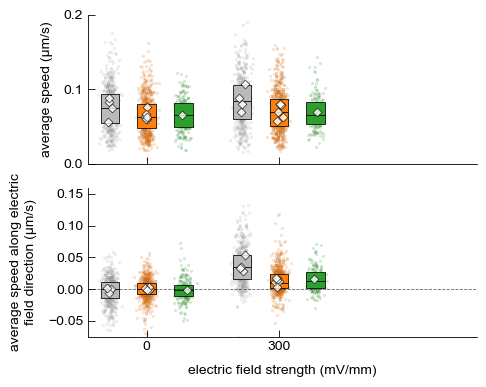

In [5]:
df_intervals_3 = parse_trajectories(df_filtered_tracks, frame_step=3)
E_levels = [0, 3]
celltypes = [wt, ko1, ko2]


displacement_records_mag = []

# Assume z column exists in df_intervals_3
for (celltype, E), group in df_intervals_3[df_intervals_3.E_V_cm.isin([0, 1, 3])].groupby(['celltype', 'E_V_cm']):
    for (date, trial, user, cell), d in group.groupby(['date', 'trial', 'user', 'cell']):
        if len(d) <= 3:
            continue
        d = d.sort_values('interval')
        dx = np.diff(d['x'].values)
        dy = np.diff(d['y'].values)
        dz = np.diff(d['z'].values)
        if len(dx) == 0:
            continue
        speeds = [sqrt(dx[i]**2 + dy[i]**2 + dz[i]**2) for i in range(len(dx))]
        mean_speed = np.mean(speeds)
        displacement_records_mag.append({
            'celltype': celltype,
            'E_V_cm': E,
            'date': date,
            'trial': trial,
            'user': user,
            'cell': cell,
            'mean_speed': mean_speed / (3.0 * 60.0)  # Normalize for 3-frame interval (in μm/s)
        })

df_displacement_mag = pd.DataFrame(displacement_records_mag)

displacement_records = []

for (celltype, E), group in df_intervals_3.groupby(['celltype', 'E_V_cm']):
    for (date, trial, user, cell), d in group.groupby(['date', 'trial', 'user', 'cell']):
        if len(d) <= 3:
            continue
        d = d.sort_values('interval')
        dx = np.diff(d['x'].values)
        if len(dx) == 0:
            continue
        mean_dx = np.mean(dx)
        displacement_records.append({
            'celltype': celltype,
            'E_V_cm': E,
            'date': date,
            'trial': trial,
            'user': user,
            'cell': cell,
            'mean_dx': mean_dx
        })

df_displacement_proj = pd.DataFrame(displacement_records)

# Normalize speed
df_displacement_proj['mean_speed'] = df_displacement_proj['mean_dx'] / (3.0 * 60.0)


######################
df_mag_plot = df_displacement_mag[df_displacement_mag.E_V_cm.isin([0, 1, 3])]
df_proj_plot = df_displacement_proj[df_displacement_proj.E_V_cm.isin([0, 1, 3])]


# Calculate average values per replicate for magnitude and projection
avg_mag_replicate = (
    df_mag_plot.groupby(['date', 'trial', 'user', 'E_V_cm', 'celltype'], as_index=False)
    ['mean_speed'].mean()
)

avg_proj_replicate = (
    df_proj_plot.groupby(['date', 'trial', 'user', 'E_V_cm', 'celltype'], as_index=False)
    ['mean_speed'].mean()
)

# Perform statistical tests (Mann-Whitney U) comparing averages of each replicate
from scipy.stats import mannwhitneyu

def run_stats(avg_df, E_levels, cell_a, cell_b):
    results = {}
    for E in E_levels:
        subset_a = avg_df[(avg_df.celltype == cell_a) & (avg_df.E_V_cm == E)]['mean_speed']
        subset_b = avg_df[(avg_df.celltype == cell_b) & (avg_df.E_V_cm == E)]['mean_speed']

        if len(subset_a) > 0 and len(subset_b) > 0:
            stat, p = mannwhitneyu(subset_a, subset_b, alternative='two-sided')
            results[E] = {'U_stat': stat, 'p_value': p, 'n_a': len(subset_a), 'n_b': len(subset_b)}
    return results

# Compare replicate-level averages
cell_wt = 'dHL60KW'
cell_ko1 = 'dHL60TMEM154KO-clone1'
cell_ko2 = 'dHL60TMEM154KO-clone12'

print("\nMagnitude comparisons (KO1 vs WT):", run_stats(avg_mag_replicate, E_levels, cell_ko1, cell_wt))
print("\nMagnitude comparisons (KO2 vs WT):", run_stats(avg_mag_replicate, E_levels, cell_ko2, cell_wt))

print("\nProjection comparisons (KO1 vs WT):", run_stats(avg_proj_replicate, E_levels, cell_ko1, cell_wt))
print("\nProjection comparisons (KO2 vs WT):", run_stats(avg_proj_replicate, E_levels, cell_ko2, cell_wt))

# Perform statistical tests using individual cell-level data

def run_stats_individual(df, E_levels, cell_a, cell_b):
    results = {}
    for E in E_levels:
        subset_a = df[(df.celltype == cell_a) & (df.E_V_cm == E)]['mean_speed']
        subset_b = df[(df.celltype == cell_b) & (df.E_V_cm == E)]['mean_speed']

        if len(subset_a) > 0 and len(subset_b) > 0:
            stat, p = mannwhitneyu(subset_a, subset_b, alternative='two-sided')
            results[E] = {'U_stat': stat, 'p_value': p, 'n_a': len(subset_a), 'n_b': len(subset_b)}
    return results

print("\n[Per-cell] Magnitude comparisons (KO1 vs WT):", run_stats_individual(df_mag_plot, E_levels, cell_ko1, cell_wt))
print("[Per-cell] Magnitude comparisons (KO2 vs WT):", run_stats_individual(df_mag_plot, E_levels, cell_ko2, cell_wt))

print("[Per-cell] Projection comparisons (KO1 vs WT):", run_stats_individual(df_proj_plot, E_levels, cell_ko1, cell_wt))
print("[Per-cell] Projection comparisons (KO2 vs WT):", run_stats_individual(df_proj_plot, E_levels, cell_ko2, cell_wt))

# Settings
colors = [color_dict[wt], color_dict[ko1], color_dict[ko2]]
celltype_color_dict = dict(zip(celltypes, colors))

group_spacing = 0.9
dodge_offset = 0.25
jitter_scale = 0.025
box_width = 0.125

# Setup 2-row figure
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(5, 4), sharex=True)

titles = ["average speed (μm/s)", "average speed along electric\nfield direction (μm/s)"]
datasets = [df_mag_plot, df_proj_plot]
avg_datasets = [avg_mag_replicate, avg_proj_replicate]

for row, (ax, df_plot, avg_plot, ylabel) in enumerate(zip(axs, datasets, avg_datasets, titles)):
    legend_entries = {}
    
    for i, E in enumerate(E_levels):
        x_base = i * group_spacing
        for j, celltype in enumerate(celltypes):
            x_pos = x_base + (j - 1) * dodge_offset
            df_subset = df_plot[(df_plot.celltype == celltype) & (df_plot.E_V_cm == E)]
            speeds = df_subset['mean_speed'].values

            if len(speeds) == 0:
                continue

            # Boxplot
            ax.boxplot(
                [speeds],
                positions=[x_pos],
                widths=box_width,
                patch_artist=True,
                showcaps=True,
                showfliers=False,
                boxprops=dict(facecolor=celltype_color_dict[celltype], edgecolor='black', linewidth=.56),
                medianprops=dict(color='black', linewidth=0.6),
                whiskerprops=dict(color='black', linewidth=0),
                capprops=dict(color='black', linewidth=0),
            )

            # Jittered scatter (individual points)
            jittered_x = np.random.normal(loc=x_pos, scale=jitter_scale, size=len(speeds))
            scatter = ax.scatter(
                jittered_x, speeds,
                s=4, color=celltype_color_dict[celltype],
                alpha=0.2, edgecolor='black', linewidth=0.1,
                label=celltype if (E == 0 and celltype not in legend_entries) else None
            )
            legend_entries[celltype] = scatter

            # Scatter average replicate points
            avg_subset = avg_plot[(avg_plot.celltype == celltype) & (avg_plot.E_V_cm == E)]
            if not avg_subset.empty:
                avg_x = np.random.normal(loc=x_pos, scale=jitter_scale/2, size=len(avg_subset))
                ax.scatter(
                    avg_x, avg_subset['mean_speed'],
                    s=20, alpha=0.8,
                    marker='D', linewidth=0.5, edgecolor='black', color='white',#edgecolor='white', color='black',
                    zorder=5
                )

    # Formatting
    xticks = [i * group_spacing for i in range(len(E_levels))]
    xticklabels = [str(e * 100) for e in E_levels]
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, fontsize=10)
    ax.set_xlim(-0.4, 2.25)
    ax.set_ylabel(ylabel, fontsize=10)
    
    ax.grid(False)

    if ylabel == "average speed (μm/s)":
        yticks = [0,0.1, 0.2]
        ax.set_yticks(yticks)
        ax.set_ylim(0,0.2)
    else:
        ax.hlines(y=0, xmin=-1, xmax=3 + box_width, color='black', linestyle='--', linewidth=0.6, alpha=0.6)
        yticks = [-0.05,0.0, 0.05, 0.1, 0.15]
        ax.set_yticks(yticks)
        ax.set_ylim(-0.075,0.16)

    for spine in ['bottom', 'left']:
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', colors='black', width=0.6, length=5)
    ax.tick_params(axis='y', labelsize=10)

# Shared xlabel
axs[1].set_xlabel("electric field strength (mV/mm)", fontsize=10)

plt.tight_layout()
# fig.savefig('../../figures/Figure2_supplement_speeds_updated.pdf')